CSV files loaded


C:\Users\Coder\AppData\Local\Temp\ipykernel_3632\231520897.py:42: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\Coder\AppData\Local\Temp\ipykernel_3632\231520897.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside


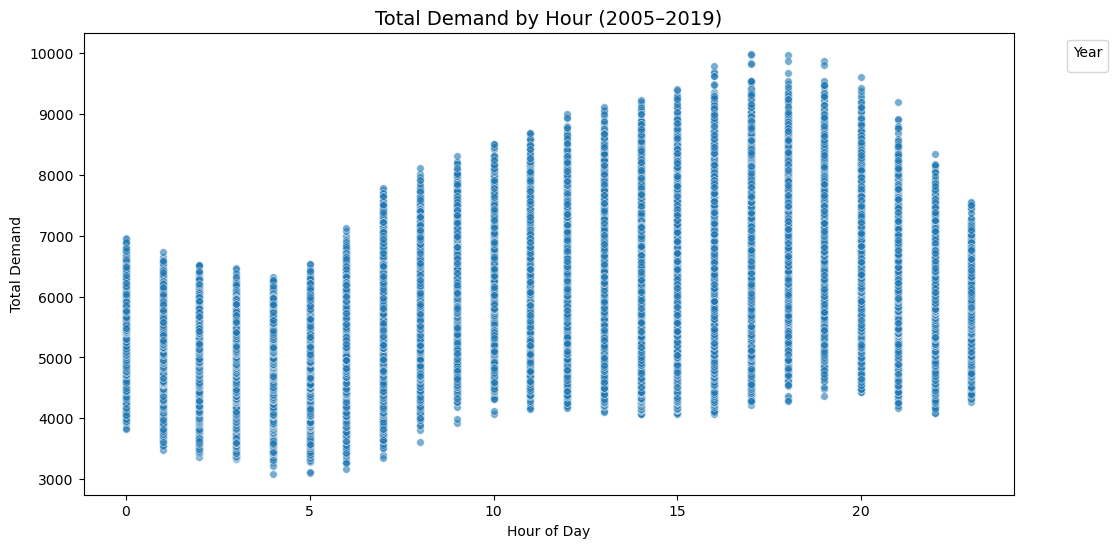

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/QLD_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)  # Remove timezone
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()




# Scatter plot with color by year
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Hour",
    y="Total Demand",
    palette="tab20",       # 20 distinct colors (good for many years)
    legend="full",
    s=30,                  # marker size
    alpha=0.6              # transparency
)

plt.title("Total Demand by Hour (2005–2019)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Demand")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.show()

C:\Users\Coder\AppData\Local\Temp\ipykernel_3632\4043686329.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\Coder\AppData\Local\Temp\ipykernel_3632\4043686329.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside


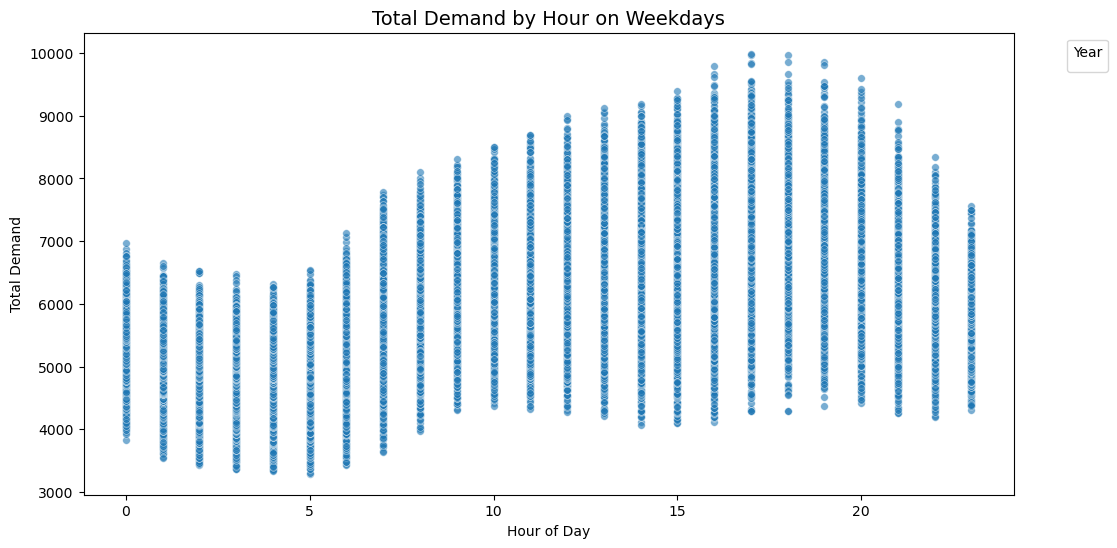

In [5]:
# Filter for weekends (Saturday and Sunday)
df_weekends = df[df['Day'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thuresday', 'Friday'])]

# Scatter plot with color by year for weekends only
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_weekends,
    x="Hour",
    y="Total Demand",
    palette="tab20",       # 20 distinct colors (good for many years)
    legend="full",
    s=30,                  # marker size
    alpha=0.6              # transparency
)

plt.title("Total Demand by Hour on Weekdays", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Demand")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.show()

C:\Users\Coder\AppData\Local\Temp\ipykernel_3632\886337118.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\Coder\AppData\Local\Temp\ipykernel_3632\886337118.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside


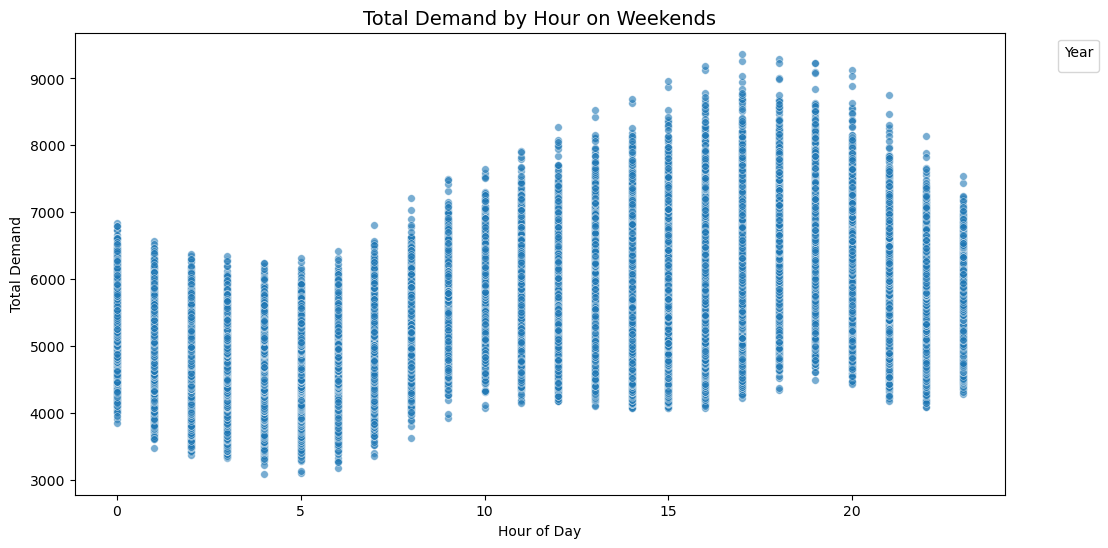

In [13]:
# Filter for weekends (Saturday and Sunday)
df_weekends = df[df['Day'].isin(['Saturday', 'Sunday'])]

# Scatter plot with color by year for weekends only
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_weekends,
    x="Hour",
    y="Total Demand",
    palette="tab20",       # 20 distinct colors (good for many years)
    legend="full",
    s=30,                  # marker size
    alpha=0.6              # transparency
)

plt.title("Total Demand by Hour on Weekends", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Demand")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.show()

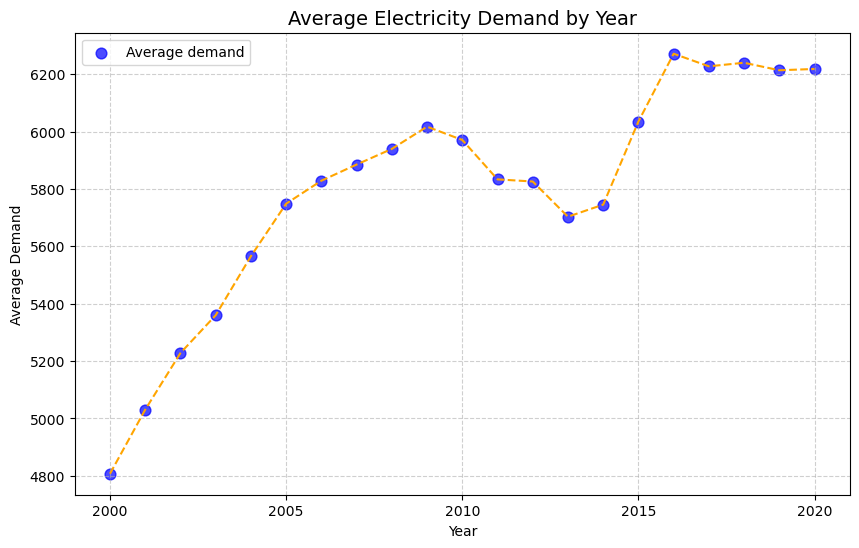

In [8]:

# Extract year column
df['Year'] = df['Datetime'].dt.year

# Compute average demand per year
avg_demand_year = df.groupby('Year')['Total Demand'].mean().reset_index()

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    avg_demand_year['Year'], 
    avg_demand_year['Total Demand'], 
    color='blue', 
    s=60, 
    alpha=0.7,
    label="Average demand"
)

plt.plot(avg_demand_year['Year'], avg_demand_year['Total Demand'], color='orange', linestyle='--')  # optional trend line

# Set x-axis ticks to show only 2000, 2005, 2010, ...
plt.xticks(np.arange(2000, avg_demand_year['Year'].max() + 1, 5))

plt.title("Average Electricity Demand by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Demand")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

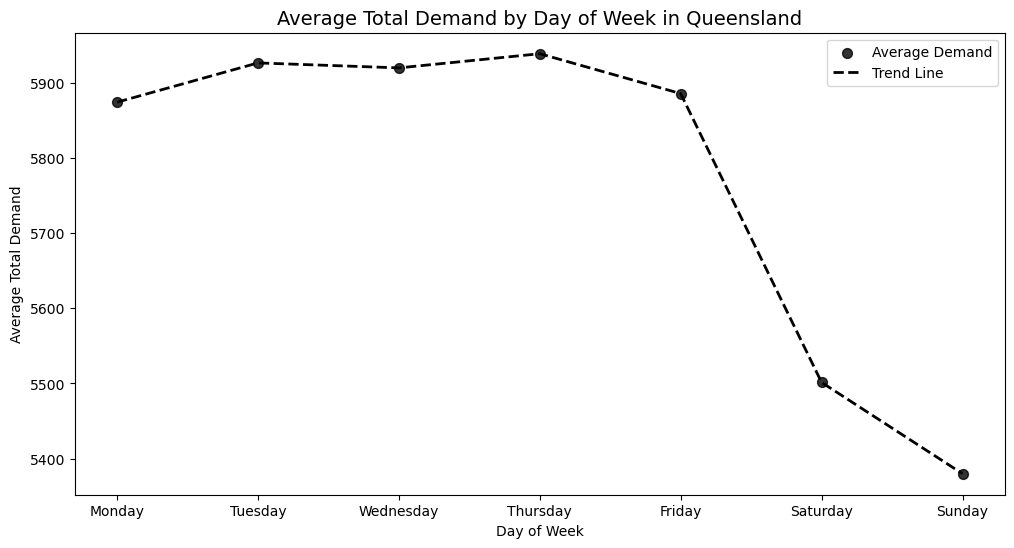

Average Total Demand by Day of Week:
Day
Monday       5874.41
Tuesday      5926.70
Wednesday    5920.08
Thursday     5938.94
Friday       5885.86
Saturday     5501.41
Sunday       5379.86
Name: Total Demand, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import pandas as pd


df['Day'] = df['Datetime'].dt.day_name()
# Define the correct order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate average total demand for each day
average_demand_by_day = df.groupby('Day')['Total Demand'].mean()

# Reindex to ensure days are ordered from Monday to Sunday
average_demand_by_day = average_demand_by_day.reindex(day_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_day.index, average_demand_by_day.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_day.index, average_demand_by_day.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Day of Week in Queensland", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show()

# Print the averages
print("Average Total Demand by Day of Week:")
print(average_demand_by_day.round(2))



Energy by Month

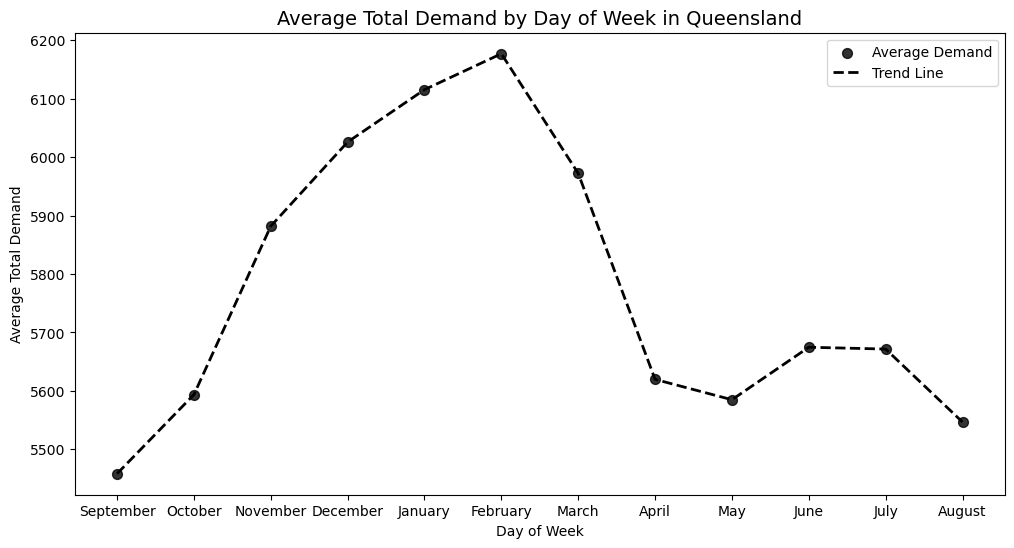

Average Total Demand by Month
Month
September    5458.22
October      5593.59
November     5881.81
December     6025.84
January      6115.51
February     6176.97
March        5972.26
April        5619.69
May          5584.85
June         5674.65
July         5671.57
August       5546.63
Name: Total Demand, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import pandas as pd


df['Month'] = df['Datetime'].dt.month_name()
# Define the correct order of days
#day_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['September', 'October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', ]

# Calculate average total demand for each day
average_demand_by_month = df.groupby('Month')['Total Demand'].mean()

# Reindex to ensure days are ordered from Monday to Sunday
average_demand_by_month = average_demand_by_month.reindex(day_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_month.index, average_demand_by_month.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_month.index, average_demand_by_month.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Day of Week in Queensland", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show()

# Print the averages
print("Average Total Demand by Month")
print(average_demand_by_month.round(2))


<function matplotlib.pyplot.show(close=None, block=None)>

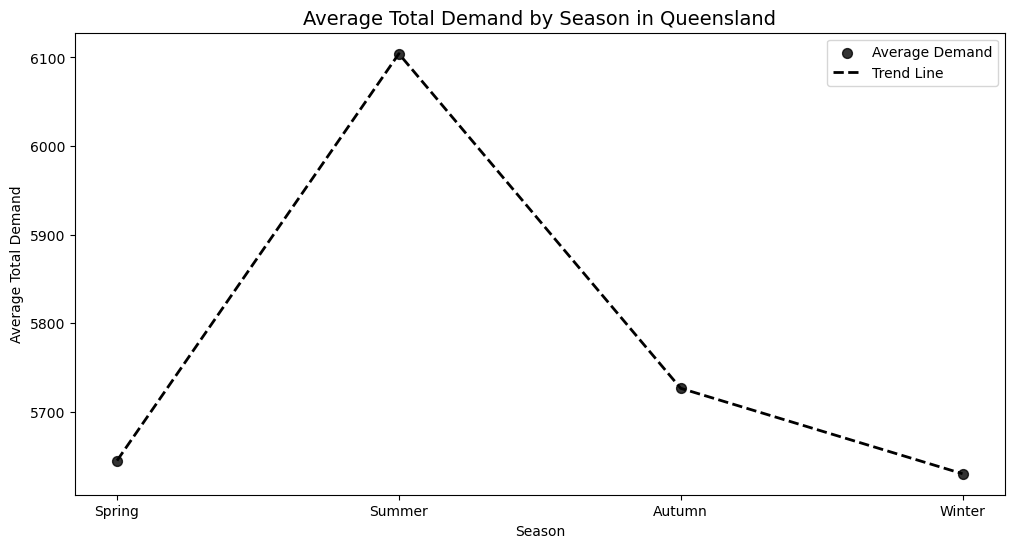

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is already defined with 'Datetime' and 'Total Demand' columns
df['Month'] = df['Datetime'].dt.month_name()

# Define seasons based on months in Tasmania
season_mapping = {
    'September': 'Spring', 'October': 'Spring', 'November': 'Spring',
    'December': 'Summer', 'January': 'Summer', 'February': 'Summer',
    'March': 'Autumn', 'April': 'Autumn', 'May': 'Autumn',
    'June': 'Winter', 'July': 'Winter', 'August': 'Winter'
}

# Add a 'Season' column to the dataframe
df['Season'] = df['Month'].map(season_mapping)

# Define the correct order of seasons
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

# Calculate average total demand for each season
average_demand_by_season = df.groupby('Season')['Total Demand'].mean()

# Reindex to ensure seasons are ordered correctly
average_demand_by_season = average_demand_by_season.reindex(season_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_season.index, average_demand_by_season.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_season.index, average_demand_by_season.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Season in Queensland", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show